In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)

import c2qa
import numpy as np
import qiskit
import sympy as sp
import qutip as qt
from custom_gates import bosonic_vqe
import matplotlib.pyplot as plt

In [3]:
values = [2, 5, 7, 3]
weights = [2.5, 3, 4, 3.5]
max_weight = 7
l_val = 3

bkp_fun1, bkp_list1 = bosonic_vqe.binary_knapsack_ham(l_val, values, weights, max_weight)
bkp_fun1

-2*x_0 - 5*x_1 - 7*x_2 - 3*x_3 + 147*(-0.357142857142857*x_0 - 0.428571428571429*x_1 - 0.571428571428571*x_2 - 0.5*x_3 - x_4/7 - 2*x_5/7 - 4*x_6/7 + 1)**2

In [4]:
bkp_list1 = bosonic_vqe.binary_to_pauli_list(bkp_fun1, bkp_list1)
bkp_ham1 = qt.Qobj( bosonic_vqe.qubit_op_to_ham(bkp_list1).full() )
print(bkp_ham1)

Quantum object: dims=[[128], [128]], shape=(128, 128), type='oper', dtype=Dense, isherm=True
Qobj data =
[[147.   0.   0. ...   0.   0.   0.]
 [  0.  27.   0. ...   0.   0.   0.]
 [  0.   0.  75. ...   0.   0.   0.]
 ...
 [  0.   0.   0. ... 346.   0.   0.]
 [  0.   0.   0. ...   0. 226.   0.]
 [  0.   0.   0. ...   0.   0. 490.]]


In [7]:
nfocks = [8,8]
ndepth = 5

en, Xvec, int_results = bosonic_vqe.ecd_opt_vqe(bkp_ham1, ndepth, nfocks, maxiter=90, method='SLSQP',
                                    verb=1, threshold=1e-3)

-------------------
iter: 10
fval: 46.790068381549425
-------------------
iter: 20
fval: 83.73710950260367
-------------------
iter: 30
fval: -4.675557435742881
-------------------
iter: 40
fval: -10.830901561197548
-------------------
iter: 50
fval: -11.583826777097208
-------------------
iter: 60
fval: -11.673177922467564
-------------------
iter: 70
fval: -11.809761056367329
-------------------
iter: 80
fval: -11.92344422419705
-------------------
iter: 90
fval: -11.981576155259939
Iteration limit reached    (Exit mode 9)
            Current function value: -11.981576155259939
            Iterations: 90
            Function evaluations: 3768
            Gradient evaluations: 90


In [8]:
P1 = bosonic_vqe.num_prob_all(Xvec,ndepth,nfocks)

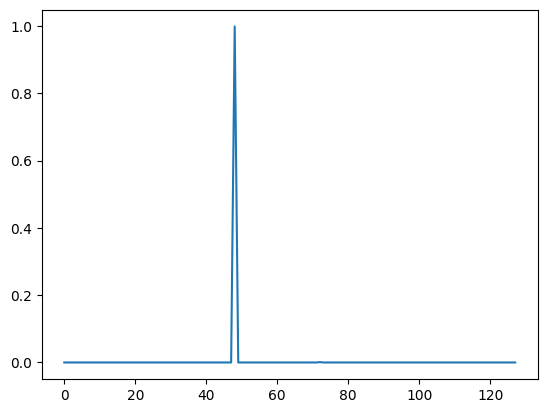

In [9]:
plt.plot(P1)